# Layer 1 fclass-only baseline

This notebook is a robustness check for the Layer 1 paved/unpaved model. It uses **only OpenStreetMap road functional class** (`fclass`) as the predictor. No Sentinel-2 or Sentinel-1 feature values are used.

The purpose is not to replace the Sentinel-only baseline in `layer1.ipynb`. It answers a different question: how much of the final model performance could be explained by OSM road hierarchy/context alone?

For a fair comparison with `testlayer1.ipynb`, the default setting filters the labelled roads to roads with Sentinel-2 feature coverage in the 2020 Ghana parquet. The S2 values are used only for the coverage filter, not as model inputs.

from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
FOCUS_CLASSES = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]
LABELS = ["paved", "unpaved"]
MATCH_S2_COVERAGE = True
COVERAGE_YEAR = 2020


def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
PBF_PATH = sorted(DATA_DIR.glob("*.osm.pbf"))[-1]

print("Repo root:", ROOT)
print("PBF:", PBF_PATH)
print("Match S2 coverage:", MATCH_S2_COVERAGE, "| coverage year:", COVERAGE_YEAR)

## 1. Build paved/unpaved labels from OSM

In [2]:
try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required. Install it in the notebook environment with: pip install pyrosm") from e


def build_osm_surface_labels(pbf_path: Path) -> pd.DataFrame:
    osm = OSM(str(pbf_path))
    roads = osm.get_network(network_type="driving").copy()
    del osm
    gc.collect()

    roads["osm_id"] = roads["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    roads["fclass"] = roads["highway"].astype(str).str.strip()
    roads = roads[roads["fclass"].isin(FOCUS_CLASSES)].copy()

    roads["surface_clean"] = roads["surface"].astype(str).str.lower().str.strip()
    roads["name_clean"] = roads.get("name", pd.Series(index=roads.index, dtype="object")).astype(str).str.strip()
    roads.loc[roads["name_clean"].isin(["", "nan", "None"]), "name_clean"] = np.nan

    paved_vals = {
        "paved", "asphalt", "concrete", "paving_stones", "concrete:plates",
        "sett", "cobblestone", "metal", "bricks", "cement", "chipseal",
    }
    unpaved_vals = {
        "unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel",
        "sand", "mud", "grass", "compacted", "pebblestone", "soil",
    }

    roads["surface_label"] = np.where(
        roads["surface_clean"].isin(paved_vals), "paved",
        np.where(roads["surface_clean"].isin(unpaved_vals), "unpaved", None),
    )

    # Same named-road fill logic as layer1/testlayer1:
    # if a named road has only one known surface label, use it for unnamed/missing segments with that name.
    name_known = roads.dropna(subset=["name_clean", "surface_label"]).copy()
    name_stats = (
        name_known.groupby("name_clean")["surface_label"]
        .agg(lambda s: sorted(set(s.dropna().tolist())))
        .to_frame("classes")
    )
    name_stats["n_classes"] = name_stats["classes"].apply(len)
    name_stats["inferred_label"] = np.where(
        name_stats["n_classes"] == 1,
        name_stats["classes"].apply(lambda x: x[0]),
        np.nan,
    )
    name_to_label = name_stats["inferred_label"].dropna()

    missing_before = roads["surface_label"].isna().sum()
    fill_mask = roads["surface_label"].isna() & roads["name_clean"].notna()
    roads.loc[fill_mask, "surface_label"] = roads.loc[fill_mask, "name_clean"].map(name_to_label)
    missing_after = roads["surface_label"].isna().sum()

    labels = (
        roads[["osm_id", "fclass", "name_clean", "surface_label"]]
        .loc[lambda d: d["surface_label"].isin(LABELS)]
        .drop_duplicates(subset=["osm_id"])
        .rename(columns={"surface_label": "layer1_label"})
        .reset_index(drop=True)
    )

    print("Named-road labels filled:", int(missing_before - missing_after))
    print("Labelled rows before S2 coverage filter:", len(labels))
    print(labels["layer1_label"].value_counts(normalize=True).mul(100).round(2))
    return labels


labels_df = build_osm_surface_labels(PBF_PATH)
labels_df.head()

/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Named-road labels filled: 1784
Labelled rows before S2 coverage filter: 31650
layer1_label
unpaved    54.61
paved      45.39
Name: proportion, dtype: float64


,osm_id,fclass,name_clean,layer1_label
0,4790591,unclassified,Airport Road,paved
1,4790592,residential,Nortei Ababio Road,paved
2,4790594,tertiary,Airport Road,paved
3,4790596,unclassified,Airport Road,paved
4,4790597,residential,Volta Road,paved


## 2. Optional coverage filter for fair comparison

In [3]:
def load_s2_coverage_ids(year: int) -> set[str]:
    year_dir = DATA_DIR / "ghana_parquet" / f"year={year}"
    files = sorted(year_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found in {year_dir}")
    s2 = pd.read_parquet(files[0], columns=["osm_id"]).copy()
    s2["osm_id"] = s2["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    return set(s2["osm_id"].unique())


if MATCH_S2_COVERAGE:
    coverage_ids = load_s2_coverage_ids(COVERAGE_YEAR)
    before = len(labels_df)
    labels_df = labels_df[labels_df["osm_id"].isin(coverage_ids)].copy()
    print(f"Filtered to roads with {COVERAGE_YEAR} S2 coverage: {before:,} -> {len(labels_df):,}")

print("Final fclass-only modelling rows:", len(labels_df))
print("Unique osm_id:", labels_df["osm_id"].nunique())
print("Class balance (%):")
display(labels_df["layer1_label"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))
print("Road class distribution:")
display(labels_df["fclass"].value_counts().to_frame("count"))

Filtered to roads with 2020 S2 coverage: 31,650 -> 31,399
Final fclass-only modelling rows: 31399
Unique osm_id: 31399
Class balance (%):


,percent
layer1_label,
unpaved,54.54
paved,45.46


Road class distribution:


,count
fclass,
residential,13917
unclassified,6361
service,4413
tertiary,2368
secondary,1663
trunk,1525
primary,1152


## 3. fclass-only feature matrix

In [4]:
model_df = labels_df.copy()
model_df["fclass"] = pd.Categorical(model_df["fclass"], categories=FOCUS_CLASSES)
X = pd.get_dummies(model_df["fclass"], prefix="fclass", dtype=float)
y = model_df["layer1_label"].copy()

# Group by clean road name where available, otherwise by OSM id, matching the logic used in the main notebooks.
model_df["group_id"] = np.where(
    model_df["name_clean"].notna(),
    "name::" + model_df["name_clean"].astype(str),
    "osm::" + model_df["osm_id"].astype(str),
)
groups = model_df["group_id"].copy()

print("Feature columns:", X.columns.tolist())
print("Rows:", len(X), "| groups:", groups.nunique())
display(X.head())

Feature columns: ['fclass_residential', 'fclass_service', 'fclass_trunk', 'fclass_primary', 'fclass_secondary', 'fclass_tertiary', 'fclass_unclassified']
Rows: 31399 | groups: 25639


,fclass_residential,fclass_service,fclass_trunk,fclass_primary,fclass_secondary,fclass_tertiary,fclass_unclassified
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. GroupKFold model comparison

In [ ]:
models = {
    "dummy_majority": DummyClassifier(strategy="most_frequent"),
    "logistic": Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

try:
    from xgboost import XGBClassifier
    models["xgboost"] = XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
except Exception:
    print("xgboost not installed; skipping xgboost.")


label_map = {"paved": 0, "unpaved": 1}
inv_label_map = {v: k for k, v in label_map.items()}


def evaluate_models_grouped(X, y, groups, models, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    rows = []
    oof = {}

    for model_name, estimator in models.items():
        y_true_all, y_pred_all = [], []

        for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), start=1):
            est = clone(estimator)
            Xtr, Xte = X.iloc[tr], X.iloc[te]
            ytr, yte = y.iloc[tr], y.iloc[te]

            if model_name == "xgboost":
                est.fit(Xtr, ytr.map(label_map))
                pred = pd.Series(est.predict(Xte)).map(inv_label_map).to_numpy()
            else:
                est.fit(Xtr, ytr)
                pred = est.predict(Xte)

            p_, r_, f1_, _ = precision_recall_fscore_support(
                yte, pred, labels=LABELS, zero_division=0
            )
            acc = accuracy_score(yte, pred)
            rows.append({
                "model": model_name,
                "fold": fold,
                "accuracy": acc,
                "paved_precision": p_[0],
                "paved_recall": r_[0],
                "paved_f1": f1_[0],
                "unpaved_precision": p_[1],
                "unpaved_recall": r_[1],
                "unpaved_f1": f1_[1],
                "macro_f1": float(np.mean(f1_)),
            })

            y_true_all.extend(yte.tolist())
            y_pred_all.extend(pred.tolist())

        oof[model_name] = pd.DataFrame({"true": y_true_all, "pred": y_pred_all})

    results = pd.DataFrame(rows)
    summary = (
        results.groupby("model", as_index=False)
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            paved_f1_mean=("paved_f1", "mean"),
            unpaved_f1_mean=("unpaved_f1", "mean"),
            paved_recall_mean=("paved_recall", "mean"),
            unpaved_recall_mean=("unpaved_recall", "mean"),
        )
        .sort_values("macro_f1_mean", ascending=False)
    )
    return results, summary, oof


cv_results, cv_summary, oof_predictions = evaluate_models_grouped(X, y, groups, models)
display(cv_summary.round(3))

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,paved_f1_mean,unpaved_f1_mean,paved_recall_mean,unpaved_recall_mean
1,logistic,0.750,0.006,0.741,0.006,0.691,0.790,0.615,0.863
2,random_forest,0.750,0.006,0.741,0.006,0.691,0.790,0.615,0.863
3,xgboost,0.750,0.006,0.741,0.006,0.691,0.790,0.615,0.863
0,dummy_majority,0.545,0.004,0.353,0.002,0.000,0.706,0.000,1.000


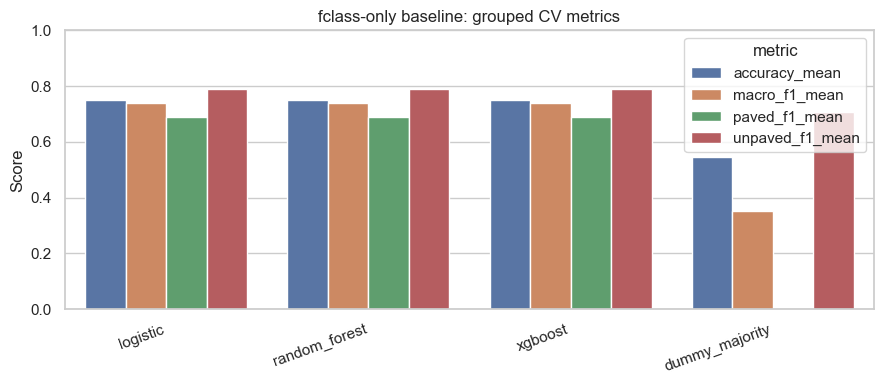

Best fclass-only model by macro-F1: logistic
              precision    recall  f1-score   support

       paved      0.789     0.615     0.691     14274
     unpaved      0.729     0.863     0.790     17125

    accuracy                          0.750     31399
   macro avg      0.759     0.739     0.741     31399
weighted avg      0.756     0.750     0.745     31399



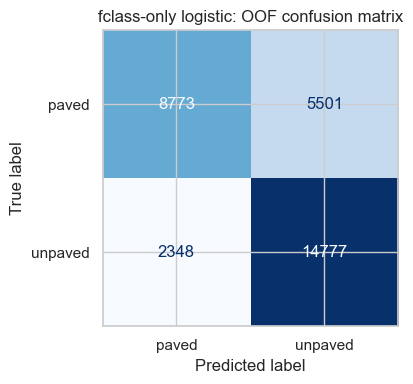

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = cv_summary.melt(
    id_vars="model",
    value_vars=["accuracy_mean", "macro_f1_mean", "paved_f1_mean", "unpaved_f1_mean"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("fclass-only baseline: grouped CV metrics")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_model_name = cv_summary.iloc[0]["model"]
best_oof = oof_predictions[best_model_name]
print("Best fclass-only model by macro-F1:", best_model_name)
print(classification_report(best_oof["true"], best_oof["pred"], labels=LABELS, digits=3, zero_division=0))

cm = confusion_matrix(best_oof["true"], best_oof["pred"], labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"fclass-only {best_model_name}: OOF confusion matrix")
plt.tight_layout()
plt.show()

## 5. Interpretability

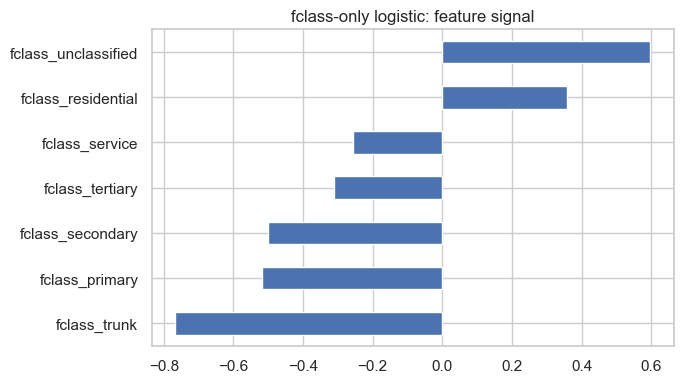

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_44557/504091102.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["fclass", "layer1_label"])


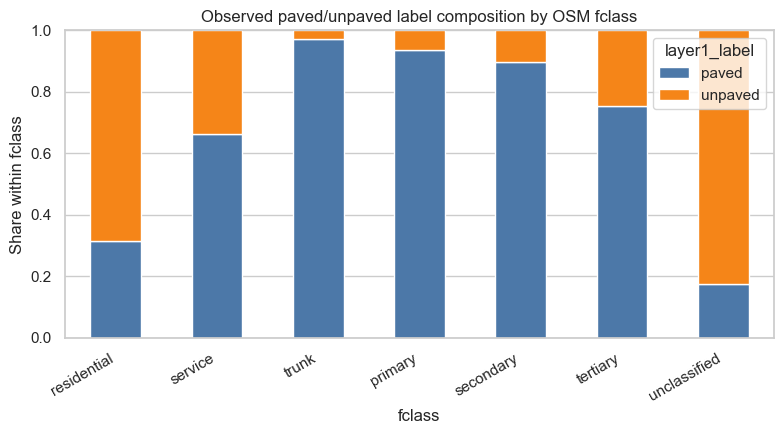

layer1_label,paved,unpaved
fclass,,
residential,4379,9538
service,2933,1480
trunk,1481,44
primary,1080,72
secondary,1494,169
tertiary,1785,583
unclassified,1122,5239


In [7]:
# Fit the best model on all rows for a simple fclass importance/association view.
best_est = clone(models[best_model_name])
if best_model_name == "xgboost":
    best_est.fit(X, y.map(label_map))
    if hasattr(best_est, "feature_importances_"):
        importance = pd.Series(best_est.feature_importances_, index=X.columns).sort_values(ascending=False)
    else:
        importance = pd.Series(dtype=float)
elif best_model_name == "logistic":
    best_est.fit(X, y)
    clf = best_est.named_steps["clf"]
    importance = pd.Series(clf.coef_[0], index=X.columns).sort_values()
else:
    best_est.fit(X, y)
    if hasattr(best_est, "feature_importances_"):
        importance = pd.Series(best_est.feature_importances_, index=X.columns).sort_values(ascending=False)
    else:
        importance = pd.Series(dtype=float)

if len(importance):
    fig, ax = plt.subplots(figsize=(7, 4))
    importance.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"fclass-only {best_model_name}: feature signal")
    plt.tight_layout()
    plt.show()

class_surface = (
    model_df.groupby(["fclass", "layer1_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(FOCUS_CLASSES)
)
class_surface_pct = class_surface.div(class_surface.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
class_surface_pct[LABELS].plot(kind="bar", stacked=True, ax=ax, color=["#4c78a8", "#f58518"])
ax.set_ylim(0, 1)
ax.set_ylabel("Share within fclass")
ax.set_title("Observed paved/unpaved label composition by OSM fclass")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(class_surface)

## Reporting note

Use this notebook as a small ablation:

- `layer1.ipynb`: Sentinel-only baseline.
- `layer1_class.ipynb`: OSM road-class-only baseline.
- `testlayer1.ipynb`: Sentinel + OSM road class.

If Sentinel-only is much stronger than fclass-only, the dissertation can argue that the satellite signal is doing most of the work. If fclass-only is close to the combined model, the interpretation should be more cautious.